In [ ]:
import requests, json, time, threading, os
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType,
    DoubleType, ArrayType)
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

In [ ]:
spark = SparkSession.builder.appName("Unified_Crypto_FX_Stream").getOrCreate()

CRYPTO_API = "https://api.coinranking.com/v2/coins"
CRYPTO_KEY = "coinranking5e7a77a012428158642868019f8e97982108867bbfef7826"

FX_API = "https://api.exchangerate-api.com/v4/latest/USD"
HEADERS = {"x-access-token": CRYPTO_KEY}

STREAM_DIR = "/content/market_stream"
os.makedirs(STREAM_DIR, exist_ok=True)

In [ ]:
def fx_writer():
    i = 0
    while True:
        try:
            r = requests.get(FX_API)
            if r.status_code == 200:
                idr = r.json()["rates"].get("IDR")
                if idr:
                    with open(f"{STREAM_DIR}/fx_{i}.json", "w") as f:
                        json.dump({
                            "source": "fx",
                            "idr_rate": idr,
                            "timestamp": time.time()
                        }, f)
                    print(f"💱 FX update {i} | USD→IDR = {idr}")
                    i += 1
        except Exception as e:
            print("FX error:", e)

        time.sleep(15)


def crypto_writer():
    i = 0
    while True:
        try:
            r = requests.get(CRYPTO_API, headers=HEADERS)
            if r.status_code == 200:
                coins = r.json()["data"]["coins"]
                with open(f"{STREAM_DIR}/crypto_{i}.json", "w") as f:
                    json.dump({
                        "source": "crypto",
                        "records": coins,
                        "timestamp": time.time()
                    }, f)
                print(f"Crypto data update {i}")
                i += 1
        except Exception as e:
            print("Crypto error:", e)

        time.sleep(20)

threading.Thread(target=fx_writer, daemon=True).start()
threading.Thread(target=crypto_writer, daemon=True).start()
time.sleep(10)

schema = StructType([
    StructField("source", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("idr_rate", DoubleType()),
    StructField("records", ArrayType(
        StructType([
            StructField("symbol", StringType()),
            StructField("name", StringType()),
            StructField("price", StringType()),
            StructField("marketCap", StringType()),
            StructField("change", StringType())
        ])
    ))
])

df = spark.readStream.schema(schema).json(STREAM_DIR)

latest_idr = None
price_trend = {}

def unified_dashboard(batch_df, batch_id):
    global latest_idr, price_trend

    pdf = batch_df.toPandas()
    if pdf.empty:
        return

    ts = pd.Timestamp.now()

    fx_rows = pdf[pdf["source"] == "fx"]
    if not fx_rows.empty:
        latest_idr = fx_rows.iloc[-1]["idr_rate"]

    if latest_idr is None:
        print(f"⏳ Batch {batch_id}: waiting for FX rate")
        return

    crypto_rows = pdf[pdf["source"] == "crypto"]
    if crypto_rows.empty:
        print(f"⏳ Batch {batch_id}: waiting for crypto data")
        return

    coins = []
    for _, row in crypto_rows.iterrows():
        records = row["records"] or []
        for c in records:
            if "symbol" in c and "price" in c:
                coins.append({
                    "symbol": c["symbol"],
                    "price": float(c["price"]),
                    "marketCap": float(c["marketCap"]),
                    "change": float(c["change"])
                })

    if not coins:
        return

    cdf = pd.DataFrame(coins)

    cdf = cdf.sort_values("marketCap", ascending=False)
    cdf = cdf.drop_duplicates(subset="symbol")

    cdf["price_idr"] = cdf["price"] * latest_idr
    cdf["marketCap_idr"] = cdf["marketCap"] * latest_idr

    top10 = cdf.head(10)

    TRAIN_FILE = "/content/btc_training_data.csv"

    btc_row = top10[top10["symbol"] == "BTC"]
    if not btc_row.empty:
        row = {
            "timestamp": ts,
            "price_idr": btc_row.iloc[0]["price_idr"],
            "marketcap_idr": btc_row.iloc[0]["marketCap_idr"],
            "change": btc_row.iloc[0]["change"],
            "usd_idr": latest_idr
        }

        pd.DataFrame([row]).to_csv(
            TRAIN_FILE,
            mode="a",
            header=not os.path.exists(TRAIN_FILE),
            index=False
        )

    ts = pd.Timestamp.now()
    for _, r in top10.iterrows():
        price_trend.setdefault(r["symbol"], []).append((ts, r["price_idr"]))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Crypto + FX Dashboard (IDR)", fontsize=16)

    axes[0,0].bar(top10["symbol"], top10["marketCap_idr"])
    axes[0,0].set_yscale("log")
    axes[0,0].set_title("Top 10 Market Cap (IDR, log scale)")

    axes[0,1].pie(
        top10["marketCap_idr"],
        labels=top10["symbol"],
        autopct="%1.1f%%"
    )
    axes[0,1].set_title("Market Dominance")
    plt.tight_layout()

    out = f"/content/crypto_fx_dashboard_batch_{batch_id}.png"
    plt.savefig(out)
    plt.close(fig)

    print(f"Dashboard {out} saved")

query = df.writeStream.foreachBatch(unified_dashboard).outputMode("append").trigger(processingTime="10 seconds").start()
query.awaitTermination()

💱 FX update 0 | USD→IDR = 16649.97
Crypto data update 0
💱 FX update 12 | USD→IDR = 16649.97
💱 FX update 2 | USD→IDR = 16649.97
Crypto data update 9
Dashboard /content/crypto_fx_dashboard_batch_0.png saved
Crypto data update 2
💱 FX update 1 | USD→IDR = 16649.97
💱 FX update 13 | USD→IDR = 16649.97
💱 FX update 3 | USD→IDR = 16649.97
Crypto data update 1
⏳ Batch 1: waiting for crypto data
Crypto data update 10
💱 FX update 2 | USD→IDR = 16649.97
💱 FX update 14 | USD→IDR = 16649.97
💱 FX update 4 | USD→IDR = 16649.97
Crypto data update 3
Dashboard /content/crypto_fx_dashboard_batch_2.png saved
Crypto data update 2
💱 FX update 3 | USD→IDR = 16649.97
Crypto data update 11
💱 FX update 15 | USD→IDR = 16649.97
💱 FX update 5 | USD→IDR = 16649.97
Crypto data update 4
Dashboard /content/crypto_fx_dashboard_batch_3.png saved
💱 FX update 4 | USD→IDR = 16649.97
💱 FX update 16 | USD→IDR = 16649.97
Crypto data update 3
💱 FX update 6 | USD→IDR = 16649.97
⏳ Batch 4: waiting for crypto data
Crypto data updat

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt

KeyboardInterrupt



In [ ]:
df = spark.read.csv("/content/btc_training_data.csv",header=True,inferSchema=True)

df.printSchema()
df.show(5)

Crypto data update 69
root
 |-- timestamp: timestamp (nullable = true)
 |-- price_idr: double (nullable = true)
 |-- marketcap_idr: double (nullable = true)
 |-- change: double (nullable = true)
 |-- usd_idr: double (nullable = true)

+--------------------+--------------------+--------------------+------+--------+
|           timestamp|           price_idr|       marketcap_idr|change| usd_idr|
+--------------------+--------------------+--------------------+------+--------+
|2025-12-15 02:45:...|1.4899050014208484E9|2.974184121556265...| -0.92|16649.97|
|2025-12-15 02:48:...|1.4899050014208484E9|2.974184121556265...| -0.92|16649.97|
|2025-12-15 02:48:...| 1.489486760529236E9|2.973349219050346...| -0.96|16649.97|
|2025-12-15 02:49:...|1.4877684322720115E9|2.969919050943736E16| -1.07|16649.97|
|2025-12-15 02:49:...| 1.487082233597318E9|2.968549244680105...| -1.12|16649.97|
+--------------------+--------------------+--------------------+------+--------+
only showing top 5 rows


In [ ]:
dfsave=df

In [ ]:
dfsave.write.mode("overwrite").option("header", True).csv("/content/dfsave_csv")

In [ ]:
numeric_cols = ["price_idr","marketcap_idr","change","usd_idr"]

for c in numeric_cols:
    df = df.withColumn(c, col(c).cast(DoubleType()))

In [ ]:
feature_cols = ["change", "usd_idr"]
labelCol = "price_idr"

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

ml_df = assembler.transform(df)
ml_df.select("features", "price_idr").show(5, truncate=False)

+----------------+--------------------+
|features        |price_idr           |
+----------------+--------------------+
|[-0.92,16649.97]|1.4899050014208484E9|
|[-0.92,16649.97]|1.4899050014208484E9|
|[-0.96,16649.97]|1.489486760529236E9 |
|[-1.07,16649.97]|1.4877684322720115E9|
|[-1.12,16649.97]|1.487082233597318E9 |
+----------------+--------------------+
only showing top 5 rows


In [ ]:
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

Crypto data update 71


In [ ]:
lr = LinearRegression(featuresCol="features",labelCol="price_idr")
lr_model = lr.fit(train_df)

In [ ]:
predictions = lr_model.transform(test_df)

evaluator_rmse = RegressionEvaluator(
    labelCol="price_idr",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="price_idr",
    predictionCol="prediction",
    metricName="r2"
)

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("RMSE:", rmse)
print("R2:", r2)


RMSE: 499800.94419286656
R2: 0.2170114508543406


In [ ]:
print("Intercept:", lr_model.intercept)

for col_name, coef in zip(feature_cols, lr_model.coefficients):
    print(f"{col_name}: {coef}")


Intercept: 1492228580.6375148
change: 10348155.136632433
usd_idr: 0.0


In [ ]:
predictions.select(
    "price_idr",
    "prediction"
).show(10, truncate=False)

+--------------------+--------------------+
|price_idr           |prediction          |
+--------------------+--------------------+
|1.478149754457471E9 |1.4783620527544274E9|
|1.477942396120788E9 |1.4781550896516948E9|
|1.4777484907215347E9|1.4781550896516948E9|
|1.4764585394731383E9|1.4773272372407641E9|
|1.4771979053292983E9|1.4777411634462295E9|
|1.476598858317222E9 |1.4772237556893978E9|
|1.4770725326204967E9|1.4775342003434968E9|
|1.477362856925384E9 |1.4777411634462295E9|
|1.4779204313735049E9|1.4773272372407641E9|
|1.4784135895999327E9|1.4777411634462295E9|
+--------------------+--------------------+
only showing top 10 rows


In [ ]:
pdf = predictions.select(
    "price_idr",
    "prediction"
).toPandas()

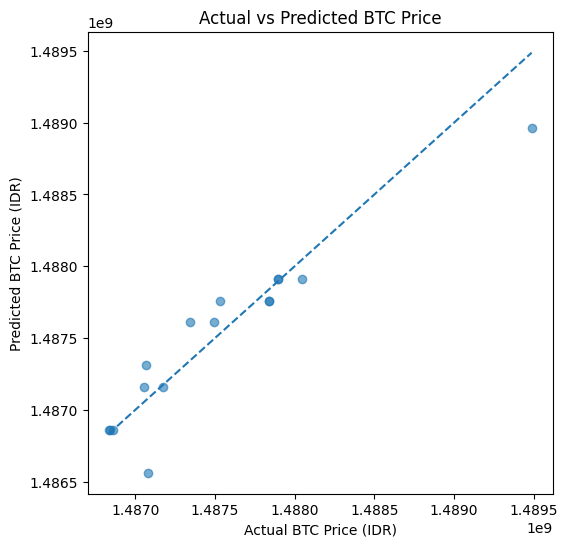

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(pdf["price_idr"], pdf["prediction"], alpha=0.6)
plt.plot(
    [pdf["price_idr"].min(), pdf["price_idr"].max()],
    [pdf["price_idr"].min(), pdf["price_idr"].max()],
    linestyle="--"
)

plt.xlabel("Actual BTC Price (IDR)")
plt.ylabel("Predicted BTC Price (IDR)")
plt.title("Actual vs Predicted BTC Price")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    pdf["timestamp"],
    pdf["price_idr"],
    label="Actual Price (IDR)",
    marker="o"
)

plt.plot(
    pdf["timestamp"],
    pdf["prediction"],
    label="Predicted Price (IDR)",
    linestyle="--",
    marker="x"
)

plt.title("BTC Price: Actual vs Predicted (IDR)")
plt.xlabel("Time")
plt.ylabel("Price (IDR)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


NameError: name 'pdf' is not defined

<Figure size 1400x600 with 0 Axes>